<a href="https://colab.research.google.com/github/MdShajalalsojib/Data-Mining-Lab/blob/main/Lab_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

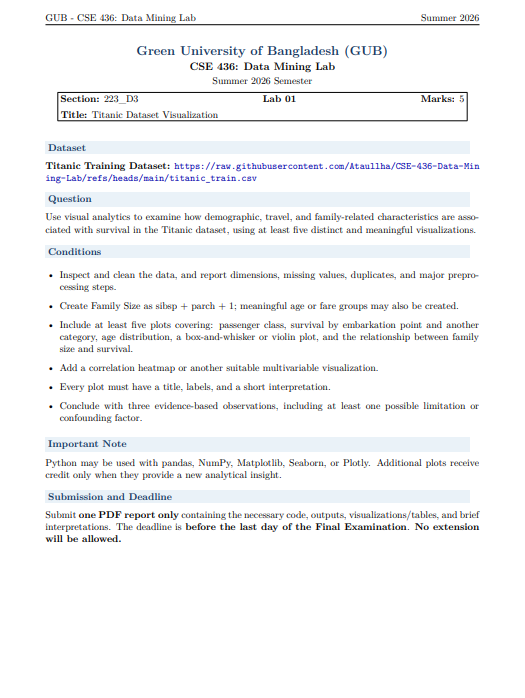

# **Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Load the Dataset**

In [2]:
url = "https://raw.githubusercontent.com/Ataullha/CSE-436-Data-Mining-Lab/refs/heads/main/titanic_train.csv"

df = pd.read_csv(url)

# **Initial Dataset Inspection**

In [3]:
print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Dataset Dimensions ---")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n--- Column Names ---")
print(df.columns.tolist())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Dataset Information ---")
df.info()


--- First 5 Rows ---
   passenger_id  pclass                                               name  \
0          1216       3                                 Smyth, Miss. Julia   
1           699       3                                    Cacic, Mr. Luka   
2          1267       3  Van Impe, Mrs. Jean Baptiste (Rosalie Paula Go...   
3           449       2              Hocking, Mrs. Elizabeth (Eliza Needs)   
4           576       2                                    Veal, Mr. James   

      sex   age  sibsp  parch  ticket     fare cabin embarked boat  body  \
0  female   NaN      0      0  335432   7.7333   NaN        Q   13   NaN   
1    male  38.0      0      0  315089   8.6625   NaN        S  NaN   NaN   
2  female  30.0      1      1  345773  24.1500   NaN        S  NaN   NaN   
3  female  54.0      1      3   29105  23.0000   NaN        S    4   NaN   
4    male  40.0      0      0   28221  13.0000   NaN        S  NaN   NaN   

                  home.dest  survived  
0           

**Missing Value Analysis**

In [4]:
print("\n" + "=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage":
        (missing_values / len(df)) * 100
})

print(missing_table)


MISSING VALUE ANALYSIS
              Missing Values  Missing Percentage
passenger_id               0            0.000000
pclass                     0            0.000000
name                       0            0.000000
sex                        0            0.000000
age                      174           20.470588
sibsp                      0            0.000000
parch                      0            0.000000
ticket                     0            0.000000
fare                       1            0.117647
cabin                    659           77.529412
embarked                   1            0.117647
boat                     542           63.764706
body                     777           91.411765
home.dest                386           45.411765
survived                   0            0.000000


**Duplicate Analysis**

In [5]:
print("\n--- Duplicate Rows ---")

duplicate_count = df.duplicated().sum()

print(
    "Number of duplicate rows:",
    duplicate_count
)


--- Duplicate Rows ---
Number of duplicate rows: 0


**Data Cleaning and Preprocessing**

In [6]:
data = df.copy()

data = data.drop_duplicates()

data["age"] = data["age"].fillna(
    data["age"].median()
)

# Embarked:
# Replace missing Embarked values
# with the most frequent category.
data["embarked"] = data["embarked"].fillna(
    data["embarked"].mode()[0]
)

# Fare:
# Replace missing Fare values with
# the median Fare.
if data["fare"].isnull().sum() > 0:
    data["fare"] = data["fare"].fillna(
        data["fare"].median()
    )

# Cabin:
# Cabin has many missing values.
# It is not required for this lab,
# so we drop the column.
if "cabin" in data.columns:
    data = data.drop(columns=["cabin"])

# Family Size:
# FamilySize = SibSp + Parch + 1
data["FamilySize"] = (
    data["sibsp"] +
    data["parch"] +
    1
)

# **Optional Meaningful Age and Family Groups**

**Age Groups**

In [7]:
data["AgeGroup"] = pd.cut(
    data["age"],
    bins=[0, 12, 18, 35, 60, np.inf],
    labels=[
        "Child",
        "Teenager",
        "Young Adult",
        "Adult",
        "Senior"
    ]
)

**Family Size Groups**

In [8]:
data["FamilyType"] = pd.cut(
    data["FamilySize"],
    bins=[0, 1, 4, 7, np.inf],
    labels=[
        "Alone",
        "Small Family",
        "Medium Family",
        "Large Family"
    ]
)

# **Visualization 1**

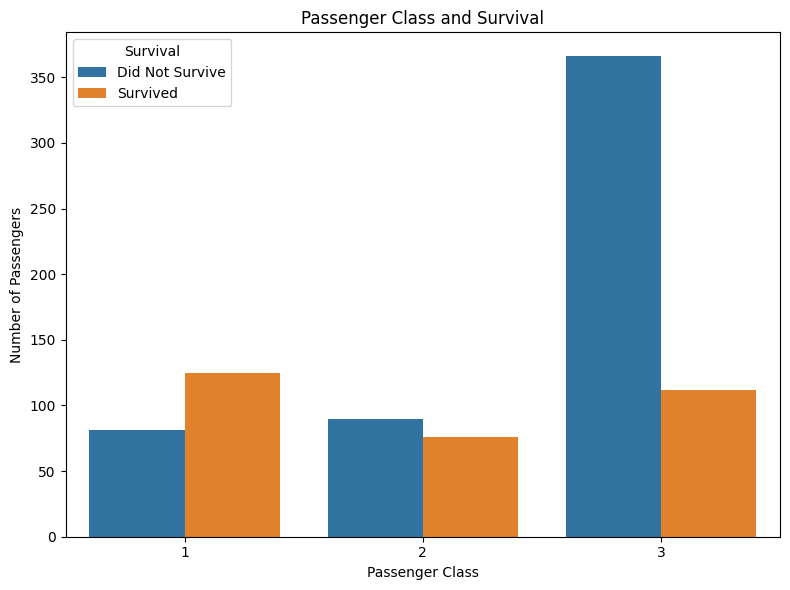

In [9]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=data,
    x="pclass",
    hue="survived"
)

plt.title(
    "Passenger Class and Survival"
)

plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.legend(
    title="Survival",
    labels=[
        "Did Not Survive",
        "Survived"
    ]
)

plt.tight_layout()
plt.show()

# **Visualization 2**

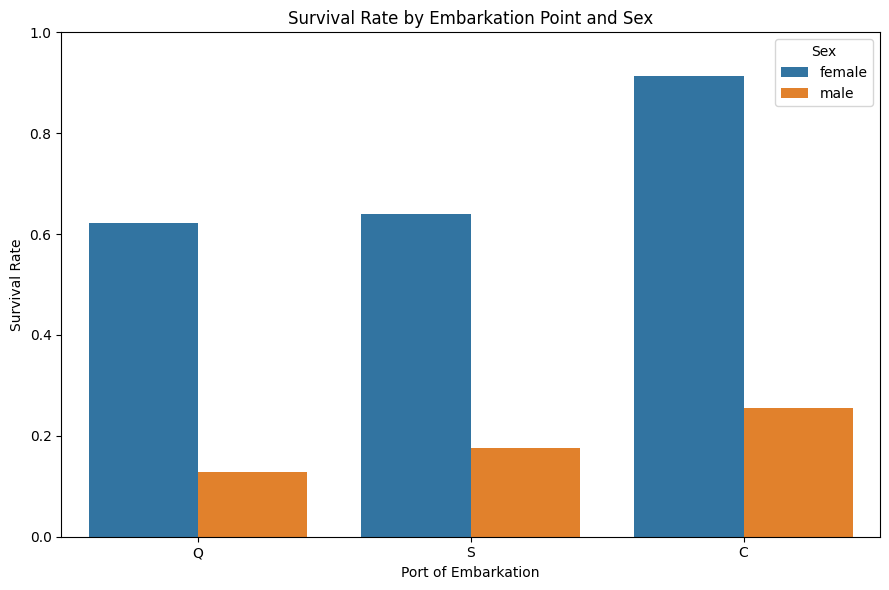

In [10]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=data,
    x="embarked",
    y="survived",
    hue="sex",
    errorbar=None
)

plt.title(
    "Survival Rate by Embarkation Point and Sex"
)

plt.xlabel("Port of Embarkation")
plt.ylabel("Survival Rate")

plt.ylim(0, 1)

plt.legend(
    title="Sex"
)

plt.tight_layout()
plt.show()

# **Visualization 3**

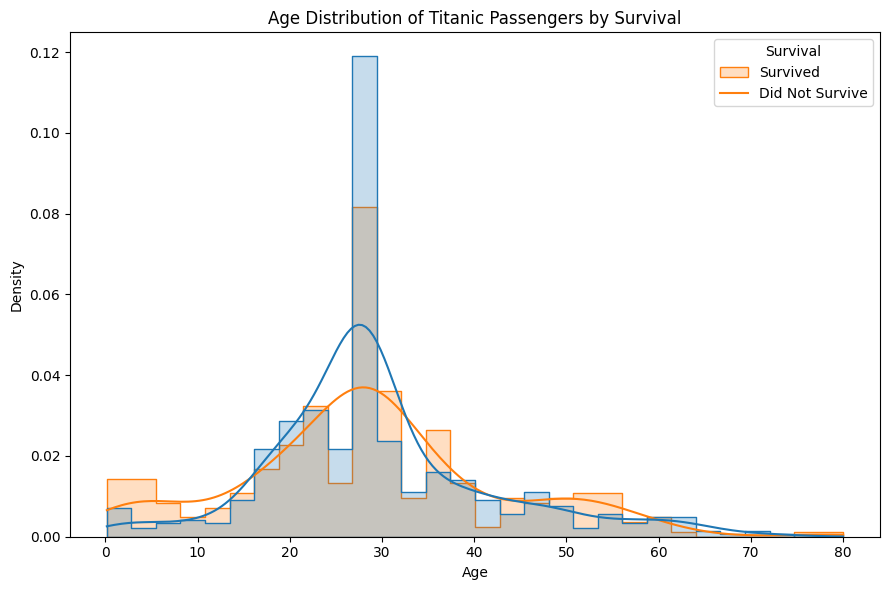

In [11]:
plt.figure(figsize=(9, 6))

sns.histplot(
    data=data,
    x="age",
    hue="survived",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title(
    "Age Distribution of Titanic Passengers by Survival"
)

plt.xlabel("Age")
plt.ylabel("Density")

plt.legend(
    title="Survival",
    labels=[
        "Survived",
        "Did Not Survive"
    ]
)

plt.tight_layout()
plt.show()

# **Visualization 4**

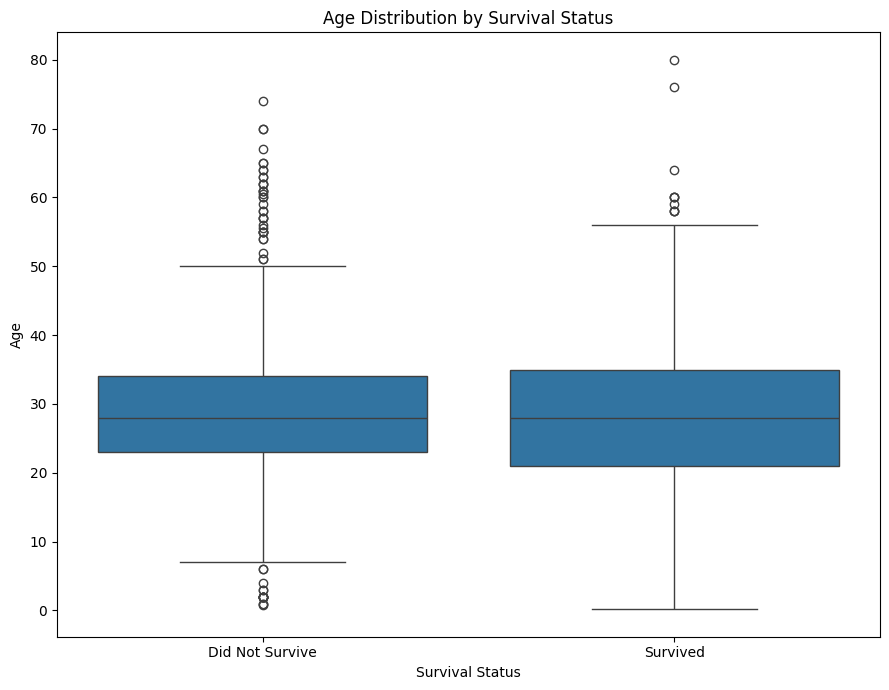

In [13]:
plt.figure(figsize=(9, 7))

sns.boxplot(
    data=data,
    x="survived",
    y="age"
)

plt.title(
    "Age Distribution by Survival Status"
)

plt.xlabel("Survival Status")
plt.ylabel("Age")

plt.xticks(
    ticks=[0, 1],
    labels=[
        "Did Not Survive",
        "Survived"
    ]
)

plt.tight_layout()
plt.show()

# **Visualization 5**

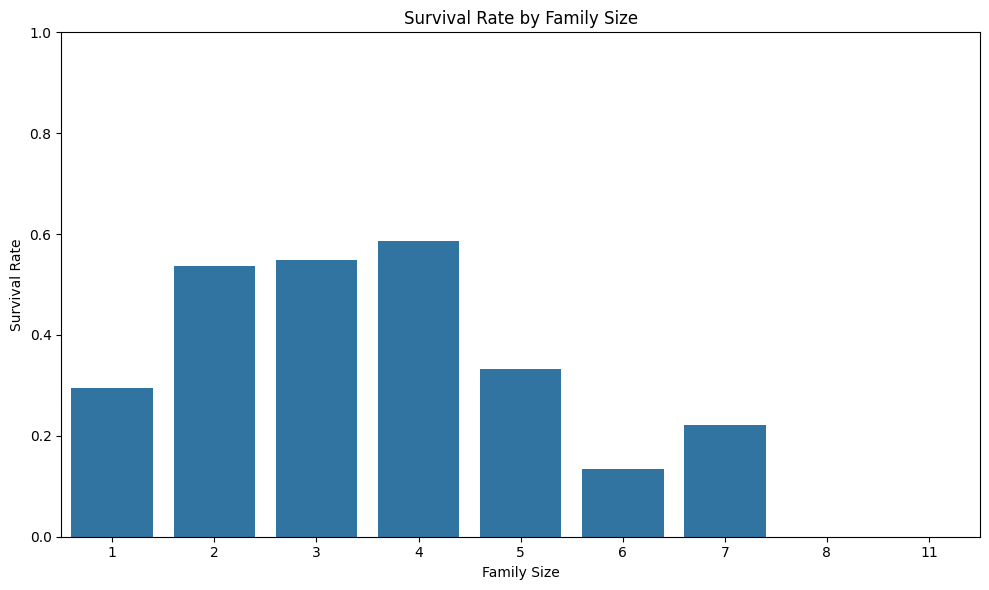

In [14]:
family_survival = (
    data.groupby(
        "FamilySize",
        observed=False
    )["survived"]
    .agg(["mean", "count"])
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=family_survival,
    x="FamilySize",
    y="mean",
    errorbar=None
)

plt.title(
    "Survival Rate by Family Size"
)

plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# **Correlation Heatmap**

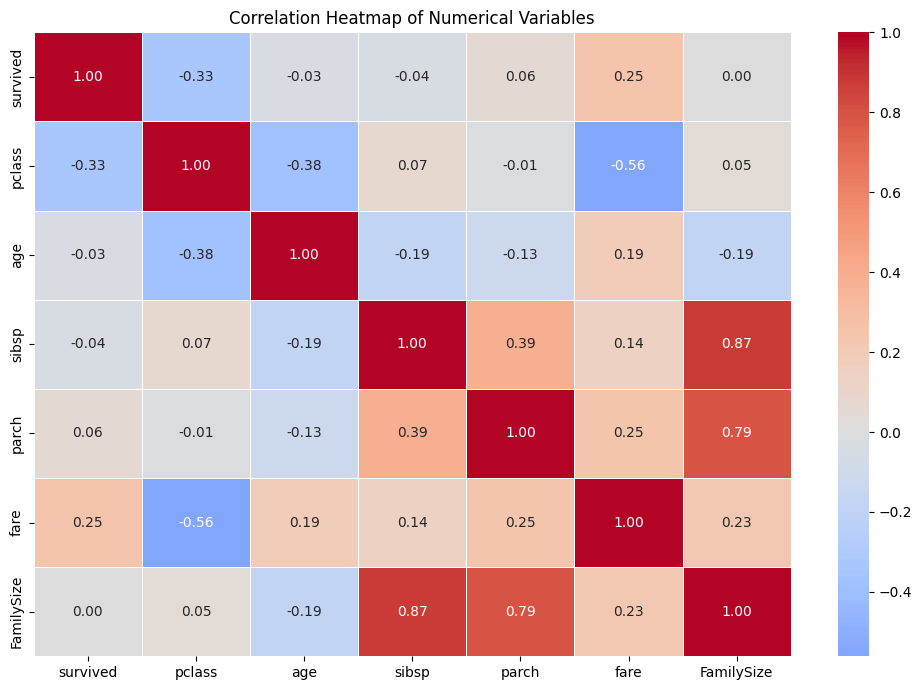

In [15]:
numeric_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "FamilySize"
]

correlation = data[
    numeric_columns
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Numerical Variables"
)

plt.tight_layout()
plt.show()

# **Survival Rate Summary Tables**

In [16]:
print("\n" + "=" * 60)
print("SURVIVAL RATE SUMMARY")
print("=" * 60)

print("\n--- Survival Rate by Passenger Class ---")

class_survival = (
    data.groupby("pclass")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print(class_survival)


print("\n--- Survival Rate by Sex ---")

sex_survival = (
    data.groupby("sex")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print(sex_survival)


print("\n--- Survival Rate by Embarkation Point ---")

embarked_survival = (
    data.groupby("embarked")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print(embarked_survival)


print("\n--- Survival Rate by Family Type ---")

family_type_survival = (
    data.groupby(
        "FamilyType",
        observed=False
    )["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print(family_type_survival)


SURVIVAL RATE SUMMARY

--- Survival Rate by Passenger Class ---
pclass
1    60.68
2    45.78
3    23.43
Name: survived, dtype: float64

--- Survival Rate by Sex ---
sex
female    70.23
male      18.69
Name: survived, dtype: float64

--- Survival Rate by Embarkation Point ---
embarked
C    51.70
Q    34.52
S    32.71
Name: survived, dtype: float64

--- Survival Rate by Family Type ---
FamilyType
Alone            29.40
Small Family     54.68
Medium Family    23.08
Large Family      0.00
Name: survived, dtype: float64
